In [2]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.utils.plots import plotting_fes_db
from flonacomldft.utils.io_utils import (
    get_project_path,
    load_csv_file
)
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima, isomers
from flonacomldft.collective_variables import get_CVs
from flonacomldft.internal_coordinates import Coordinates_mapping
from ase.io.trajectory import Trajectory
from ase.io import read

In [12]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [17]:
coord_mapping = Coordinates_mapping()
mode_names = list(isomers.keys())

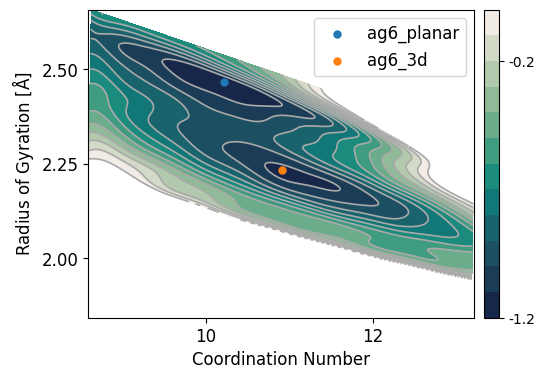

In [3]:
isomers_minima = [coord_mapping.get_internal_from_molecule(get_molecule_isomer_minima(mode_name))[0] for mode_name in mode_names]

cv_minima = np.array(get_CVs(isomers_minima)).T

fig, ax = plotting_fes_db()
for mode_name, cv in zip(mode_names, cv_minima):
    ax.scatter(*cv, marker='o', s=25, label=mode_name)
ax.legend()
fig.set_size_inches(6, 4)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [4]:
ids = np.arange(2206361, 2206365, 1)
path = get_project_path() + 'ag6_dft_calculations/structure_optimization/'
gpaw_modes = ['lcao', 'fd']

isomers_minima_recomputed = []
name_isomers = []

i = [0, 2, 1, 3]
j=0
for mode_name in mode_names:
    for gpaw_mode in gpaw_modes:
        name_isomer = '{:s}_{:s}'.format(mode_name, gpaw_mode)
        isomers_minima_recomputed.append(read(path + name_isomer + '_{:d}.out'.format(ids[i[j]])))
        name_isomers.append(name_isomer)
        j+=1

isomers_minima_recomputed = [coord_mapping.get_internal_from_molecule(isomer)[0] for isomer in isomers_minima_recomputed]

In [5]:
name_isomers

['ag6_planar_lcao', 'ag6_planar_fd', 'ag6_3d_lcao', 'ag6_3d_fd']

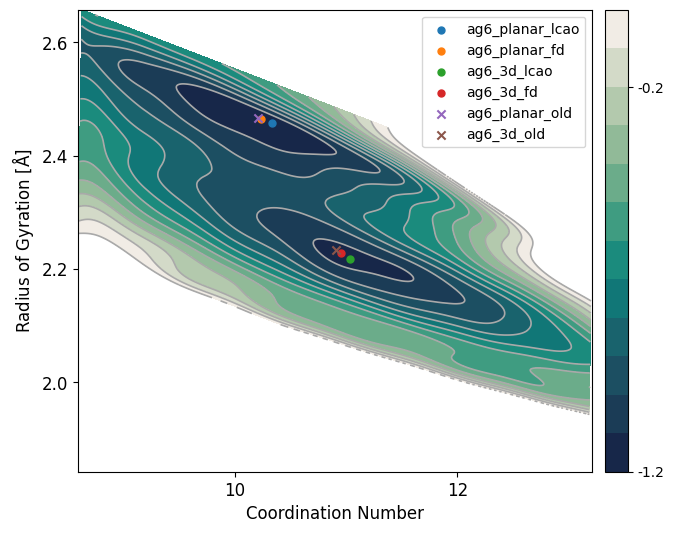

In [6]:
cv_minima_recomputed = np.array(get_CVs(isomers_minima_recomputed)).T

fig, ax = plotting_fes_db()
for name_isomer, cv in zip(name_isomers, cv_minima_recomputed):
    ax.scatter(*cv, marker='o', s=25, label=name_isomer)
for mode_name, cv in zip(mode_names, cv_minima):
    ax.scatter(*cv, marker='x', s=35, label=mode_name+'_old')
ax.legend()
fig.set_size_inches(8, 6)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [7]:
isomers_minima_recomputed = torch.stack(isomers_minima_recomputed)

Text(0.5, 0, 'internal coordinate')

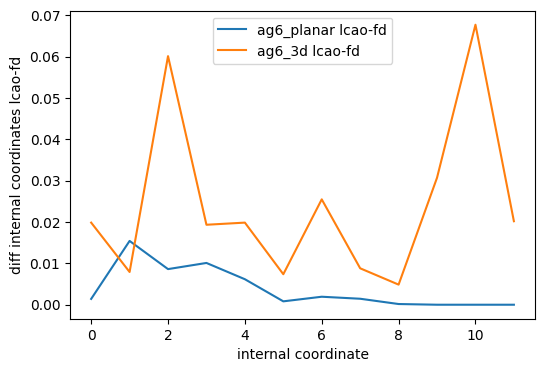

In [8]:
plt.figure(figsize = (6,4))
plt.plot(abs(isomers_minima_recomputed[0]-isomers_minima_recomputed[1]).detach().numpy(), label='ag6_planar lcao-fd')
plt.plot(abs(isomers_minima_recomputed[2]-isomers_minima_recomputed[3]).detach().numpy(), label='ag6_3d lcao-fd')
plt.legend()
plt.ylabel('diff internal coordinates lcao-fd')
plt.xlabel('internal coordinate')

In [10]:
mode_labels = [0, 1]
trajs_berendsen = [Trajectory(get_project_path() + '/database/md_trajectories/ag6_is{:d}_lcao.traj'.format(mode_label)) for mode_label in mode_labels]

temps = [[config.get_temperature() for config in traj] for traj in trajs_berendsen]

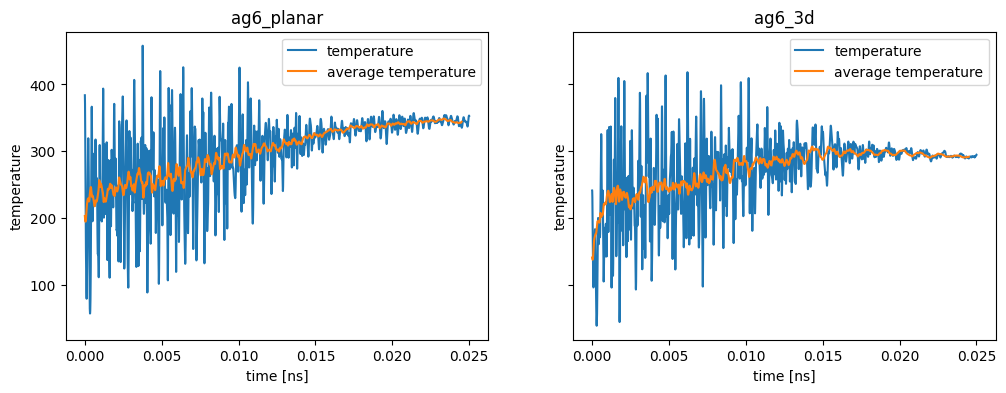

In [11]:
time = 5*np.arange(0, len(temps[0]))*1e-15*1e9

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for i in range(2):
    axs[i].plot(time, temps[i], label='temperature')
    axs[i].plot(time[:len(moving_average(temps[i], 100))], moving_average(temps[i], 100), label='average temperature')
    axs[i].legend()
    axs[i].set_title(mode_names[i])
    axs[i].set_ylabel('temperature')
    axs[i].set_xlabel('time [ns]') 

In [12]:
int_coords = [load_csv_file('int_coords/is{:d}_md_zmat.csv'.format(mode_label)) for mode_label in mode_labels]

In [13]:
int_coords[0][:, :12]

tensor([[ 2.7808,  2.6697,  2.7843,  ...,  0.0000,  0.0000, -3.1416],
        [ 2.7856,  2.6713,  2.7823,  ..., -0.0136,  0.0121, -3.1313],
        [ 2.7903,  2.6730,  2.7801,  ..., -0.0271,  0.0245, -3.1208],
        ...,
        [ 2.8081,  2.6768,  2.7850,  ..., -0.0290, -0.0320, -3.1671],
        [ 2.8086,  2.6803,  2.7838,  ..., -0.0296, -0.0323, -3.1660],
        [ 2.8089,  2.6836,  2.7827,  ..., -0.0302, -0.0327, -3.1649]])

In [14]:
cvs = [get_CVs(int_coords[i][:, :12]) for i in range(2)]

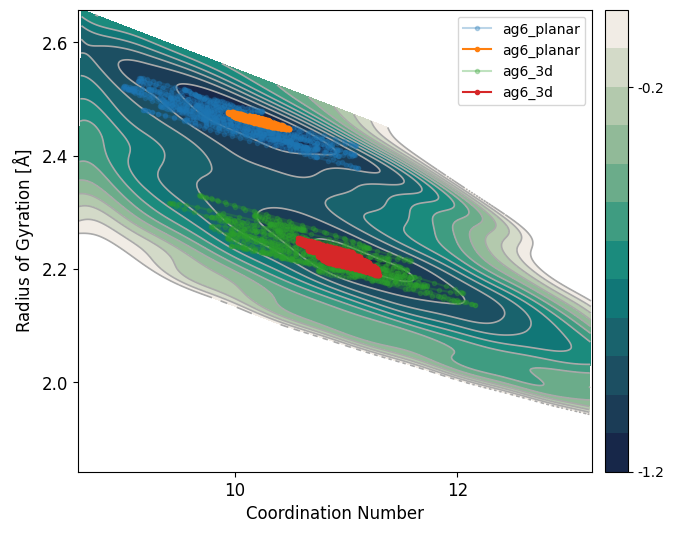

In [53]:
fig, ax = plotting_fes_db()
ax.plot(np.array(cvs[0]).T[:1000, 0], np.array(cvs[0]).T[:1000, 1], marker='.', alpha=0.3,label=mode_names[0]+' first 1000 steps');
ax.plot(np.array(cvs[0]).T[3000:, 0], np.array(cvs[0]).T[3000:, 1], marker='.', label=mode_names[0]+' last 2000 steps');
ax.plot(np.array(cvs[1]).T[:1000, 0], np.array(cvs[1]).T[:1000, 1], marker='.', alpha=0.3, label=mode_names[1]+' first 1000 steps');
ax.plot(np.array(cvs[1]).T[3000:, 0], np.array(cvs[1]).T[3000:, 1], marker='.', label=mode_names[1]+' last 2000 steps');
plt.legend()
fig.set_size_inches(8, 6)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [13]:
trajs_andersen = Trajectory(get_project_path() + 'database_andersen/ag6_md_is0_2206336.traj')

In [14]:
temps_andersen = [config.get_temperature() for config in trajs_andersen]

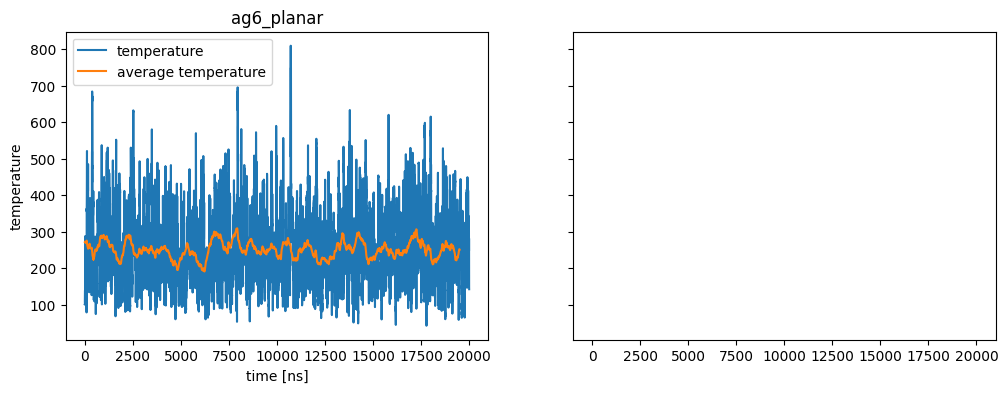

In [26]:
time_andersen = 1*np.arange(0, len(temps_andersen))#*1e-15*1e9

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for i in range(1):
    axs[i].plot(time_andersen, temps_andersen, label='temperature')
    axs[i].plot(time_andersen[:len(moving_average(temps_andersen, 500))], moving_average(temps_andersen, 500), label='average temperature')
    axs[i].legend()
    axs[i].set_title(mode_names[i])
    axs[i].set_ylabel('temperature')
    axs[i].set_xlabel('time [ns]')

In [ ]:
# Load andersen trajectories
# Train flows with the same data as for the berendsen trajectories
# Plot MH acceptance rate
# Plot FES

In [ ]:
int_coords = [load_csv_file('database_andersen/is{:d}_md_zmat.csv'.format(mode_label), get_project_path()) for mode_label in mode_labels]

In [ ]:
cvs = [get_CVs(int_coords[i][:, :12]) for i in range(2)]

In [ ]:
fig, ax = plotting_fes_db()
ax.plot(np.array(cvs[0]).T[:1000, 0], np.array(cvs[0]).T[:1000, 1], marker='.', alpha=0.3,label=mode_names[0]+' first 1000 steps');
ax.plot(np.array(cvs[0]).T[3000:, 0], np.array(cvs[0]).T[3000:, 1], marker='.', label=mode_names[0]+' last 2000 steps');
ax.plot(np.array(cvs[1]).T[:1000, 0], np.array(cvs[1]).T[:1000, 1], marker='.', alpha=0.3, label=mode_names[1]+' first 1000 steps');
ax.plot(np.array(cvs[1]).T[3000:, 0], np.array(cvs[1]).T[3000:, 1], marker='.', label=mode_names[1]+' last 2000 steps');
plt.legend()
fig.set_size_inches(8, 6)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);